# Submission Blender — Predicting Student Health Risk

Public Kaggle notebooks often converge on very similar predictions. Their leaderboard scores may differ, yet most test rows receive exactly the same label. The useful information lives in the small set of rows where strong solutions disagree.

This research builds a transparent submission pool from community outputs and previous experiments, measures how much independent signal each candidate contributes, and creates new submissions without blindly multiplying near-duplicate votes.

The workflow focuses on three questions:

- Which submissions represent genuinely different model behaviour?
- When is disagreement strong enough to justify changing the best public-score anchor?
- Which generated candidates offer distinct risk levels instead of cosmetic weight changes?

Every input is validated before analysis. Every exported blend preserves the competition schema and identifier order. Public leaderboard scores guide interpretation, but they are not treated as ground truth or optimized through large weight searches.

## Context & Methods

### Key Assumptions

- Every submission has `id` and `health_condition` columns.
- Allowed labels are `fit`, `at-risk`, and `unhealthy`.
- Scores embedded in file names or the local manifest are public leaderboard metadata, not training targets.
- Hard labels support voting, not probability averaging.
- Near-identical submissions must not receive repeated full votes.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib

matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap


@dataclass(frozen=True)
class BlendConfig:
    """Keeps paths, schema, labels, and blend constants visible in one place."""

    competition_slug: str = "playground-series-s6e7"
    dataset_slug: str = "health-submiss-pool"
    id_column: str = "id"
    target: str = "health_condition"
    labels: tuple[str, ...] = ("fit", "at-risk", "unhealthy")
    local_pool: Path = Path("../health-submiss-pool")
    kaggle_pool: Path = Path("/kaggle/input/health-submiss-pool")
    kaggle_output: Path = Path("/kaggle/working/blends")
    near_duplicate_threshold: float = 0.9995
    score_weight_scale: float = 200.0
    svg_width: int = 1080

    def resolve_pool(self) -> Path:
        """Finds the pool by structure instead of relying on Kaggle mount names."""

        candidates = [
            self.kaggle_pool,
            self.kaggle_pool / self.dataset_slug,
            self.local_pool,
            Path(self.dataset_slug),
        ]
        kaggle_input = Path("/kaggle/input")
        if kaggle_input.exists():
            candidates.extend(path.parent for path in kaggle_input.rglob("public"))
        valid = []
        for candidate in candidates:
            if (candidate / "public").is_dir() and (candidate / "mine").is_dir():
                resolved = candidate.resolve()
                if resolved not in valid:
                    valid.append(resolved)
        if len(valid) == 1:
            return valid[0]
        if not valid:
            visible = sorted(str(path) for path in kaggle_input.glob("**/*") if path.is_dir()) if kaggle_input.exists() else []
            raise FileNotFoundError(f"Submission pool not found. Kaggle directories: {visible[:40]}")
        raise RuntimeError(f"Multiple submission pools found: {valid}")

    def resolve_output(self, pool: Path) -> Path:
        """Uses Kaggle working storage online and the dataset blend folder locally."""

        return self.kaggle_output if Path("/kaggle/working").exists() else pool / "blends"


config = BlendConfig()

## Data

### 1. Load submission pool

The repository discovers CSV files from `public/` and `mine/`. A stable candidate name combines source and file stem, preventing collisions between equal scores.

In [2]:
class SubmissionRepository:
    """Loads candidate files and score metadata without manual file lists."""

    def __init__(self, config: BlendConfig):
        self.config = config
        self.pool = config.resolve_pool()
        self.output = config.resolve_output(self.pool)

    def _manifest_scores(self) -> dict[str, float]:
        """Maps local file basenames to their best recorded public score."""

        path = self.pool / "mine" / "manifest.csv"
        if not path.exists():
            return {}
        manifest = pd.read_csv(path)
        manifest["basename"] = manifest["file_name"].map(lambda value: Path(str(value)).name)
        return manifest.groupby("basename")["public_score"].max().astype(float).to_dict()

    @staticmethod
    def _score_from_name(path: Path) -> float:
        """Reads a leading numeric score from a public submission filename."""

        token = path.stem.split("_")[0]
        try:
            return float(token)
        except ValueError:
            return float("nan")

    def catalog(self) -> pd.DataFrame:
        """Builds one metadata row per prediction CSV."""

        mine_scores = self._manifest_scores()
        records = []
        for source in ("public", "mine"):
            for path in sorted((self.pool / source).glob("*.csv")):
                if path.name == "manifest.csv":
                    continue
                score = mine_scores.get(path.name, self._score_from_name(path))
                records.append(
                    {
                        "name": f"{source}:{path.stem}",
                        "source": source,
                        "file_name": path.name,
                        "path": path,
                        "public_score": float(score),
                    }
                )
        catalog = pd.DataFrame(records).sort_values(["source", "public_score", "name"], ascending=[True, False, True])
        if catalog.empty:
            raise ValueError("No submission CSV files found")
        return catalog.reset_index(drop=True)

    def load(self, catalog: pd.DataFrame) -> dict[str, pd.DataFrame]:
        """Loads every catalog entry as a two-column dataframe."""

        return {row["name"]: pd.read_csv(row["path"]) for _, row in catalog.iterrows()}


repository = SubmissionRepository(config)
catalog = repository.catalog()
submissions = repository.load(catalog)
catalog_view = catalog[["name", "source", "public_score"]].rename(columns={"name": "candidate", "public_score": "score"})
display(catalog_view.style.format({"score": "{:.5f}"}).hide(axis="index"))

candidate,source,score
mine:0.9509,mine,0.95090
mine:0.95088,mine,0.95088
mine:0.95006,mine,0.95006
mine:0.94991,mine,0.94991
mine:0.94974,mine,0.94974
public:0.95114,public,0.95114
public:0.95114_another,public,0.95114
public:0.95113,public,0.95113
public:0.95112,public,0.95112
public:0.95095,public,0.95095


### 2. Validate inputs

Validation stops early on schema drift, duplicate identifiers, missing labels, invalid classes, or mismatched row order. Blending invalid files would produce a plausible-looking but wrong submission.

In [3]:
class SubmissionValidator:
    """Enforces competition schema and row alignment before analysis."""

    def __init__(self, config: BlendConfig):
        self.config = config

    def validate(self, submissions: dict[str, pd.DataFrame]) -> pd.DataFrame:
        """Returns compact quality evidence and raises on unsafe inputs."""

        expected_columns = [self.config.id_column, self.config.target]
        reference_ids = None
        records = []
        for name, frame in submissions.items():
            schema_valid = frame.columns.tolist() == expected_columns
            unique_ids = frame[self.config.id_column].is_unique if schema_valid else False
            missing = int(frame.isna().sum().sum())
            invalid_labels = sorted(set(frame[self.config.target].dropna()) - set(self.config.labels)) if schema_valid else []
            ids = frame[self.config.id_column].to_numpy() if schema_valid else np.array([])
            if reference_ids is None:
                reference_ids = ids
            aligned = bool(np.array_equal(reference_ids, ids))
            records.append(
                {
                    "name": name,
                    "rows": len(frame),
                    "schema_valid": schema_valid,
                    "unique_ids": unique_ids,
                    "missing_values": missing,
                    "invalid_labels": ", ".join(invalid_labels),
                    "id_order_aligned": aligned,
                }
            )
        report = pd.DataFrame(records)
        safe = (
            report["schema_valid"]
            & report["unique_ids"]
            & report["id_order_aligned"]
            & report["missing_values"].eq(0)
            & report["invalid_labels"].eq("")
        )
        if not safe.all():
            raise ValueError(f"Unsafe submissions detected:\n{report.loc[~safe].to_string(index=False)}")
        if report["rows"].nunique() != 1:
            raise ValueError("Submission row counts do not match")
        return report


validator = SubmissionValidator(config)
quality_report = validator.validate(submissions)
quality_view = quality_report[["name", "rows"]].rename(columns={"name": "candidate"})
quality_view["status"] = "ready"
display(quality_view.style.hide(axis="index"))

candidate,rows,status
mine:0.9509,295753,ready
mine:0.95088,295753,ready
mine:0.95006,295753,ready
mine:0.94991,295753,ready
mine:0.94974,295753,ready
public:0.95114,295753,ready
public:0.95114_another,295753,ready
public:0.95113,295753,ready
public:0.95112,295753,ready
public:0.95095,295753,ready


## Results

### 3. Measure agreement and diversity

Agreement measures how often two submissions predict the same label. Diversity is one minus a candidate's mean agreement with all other candidates. It is descriptive evidence, not proof that a model is better.

In [4]:
class SubmissionAnalyzer:
    """Builds aligned predictions and high-signal diversity diagnostics."""

    def __init__(self, config: BlendConfig, catalog: pd.DataFrame, submissions: dict[str, pd.DataFrame]):
        self.config = config
        self.catalog = catalog.set_index("name")
        self.submissions = submissions
        first = next(iter(submissions.values()))
        self.ids = first[config.id_column].copy()
        self.predictions = pd.DataFrame({name: frame[config.target].to_numpy() for name, frame in submissions.items()})

    def agreement(self) -> pd.DataFrame:
        """Computes the pairwise share of equal hard-label predictions."""

        names = self.predictions.columns.tolist()
        values = self.predictions.to_numpy()
        matrix = np.eye(len(names), dtype=float)
        for left in range(len(names)):
            for right in range(left + 1, len(names)):
                value = float(np.mean(values[:, left] == values[:, right]))
                matrix[left, right] = value
                matrix[right, left] = value
        return pd.DataFrame(matrix, index=names, columns=names)

    def summary(self, agreement: pd.DataFrame) -> pd.DataFrame:
        """Combines score, class balance, agreement, and diversity."""

        counts = pd.DataFrame({name: self.predictions[name].value_counts() for name in self.predictions}).T.fillna(0)
        result = self.catalog[["source", "file_name", "public_score"]].copy()
        result["mean_agreement"] = (agreement.sum(axis=1) - 1) / max(len(agreement) - 1, 1)
        result["diversity"] = 1 - result["mean_agreement"]
        for label in self.config.labels:
            result[f"share_{label}"] = counts.get(label, 0) / len(self.predictions)
        return result.sort_values(["diversity", "public_score"], ascending=[False, False])

    def disagreement_strength(self) -> pd.Series:
        """Counts the size of the largest label coalition for each row."""

        return self.predictions.apply(lambda row: row.value_counts().max(), axis=1).value_counts().sort_index()


analyzer = SubmissionAnalyzer(config, catalog, submissions)
agreement = analyzer.agreement()
summary = analyzer.summary(agreement)
vote_strength = analyzer.disagreement_strength()
summary_view = summary[["source", "public_score", "diversity", "share_fit", "share_at-risk", "share_unhealthy"]].rename(columns={"public_score": "score"})
display(summary_view.style.format({"score": "{:.5f}", "diversity": "{:.3%}", "share_fit": "{:.2%}", "share_at-risk": "{:.2%}", "share_unhealthy": "{:.2%}"}))

,source,score,diversity,share_fit,share_at-risk,share_unhealthy
name,,,,,,
mine:0.9509,mine,0.95090,0.451%,7.38%,81.15%,11.47%
mine:0.95006,mine,0.95006,0.426%,7.39%,80.94%,11.68%
mine:0.94974,mine,0.94974,0.410%,7.35%,81.15%,11.50%
mine:0.94991,mine,0.94991,0.398%,7.37%,81.01%,11.62%
mine:0.95088,mine,0.95088,0.234%,7.37%,81.07%,11.56%
public:0.95081,public,0.95081,0.231%,7.39%,81.10%,11.51%
public:0.95095,public,0.95095,0.226%,7.38%,81.12%,11.50%
public:0.95113,public,0.95113,0.201%,7.38%,81.07%,11.55%
public:0.95112,public,0.95112,0.201%,7.38%,81.07%,11.55%


In [5]:
class CompetitionDataRepository:
    """Finds real competition train data across local and Kaggle mounts."""

    def __init__(self, config: BlendConfig):
        self.config = config

    def resolve_train(self) -> Path:
        """Returns train.csv containing health_condition."""
        candidates = [Path("../dataset/train.csv"), Path("dataset/train.csv")]
        kaggle_input = Path("/kaggle/input")
        if kaggle_input.exists():
            candidates.extend(kaggle_input.rglob("train.csv"))
        for candidate in candidates:
            if candidate.exists() and self.config.target in pd.read_csv(candidate, nrows=0).columns:
                return candidate
        raise FileNotFoundError("Competition train.csv with health_condition was not found")

    def load_train(self) -> pd.DataFrame:
        """Loads columns used by reality check and sample view."""
        columns = [self.config.id_column, self.config.target, "sleep_duration", "heart_rate", "bmi", "stress_level", "gender"]
        path = self.resolve_train()
        available = pd.read_csv(path, nrows=0).columns.tolist()
        return pd.read_csv(path, usecols=[column for column in columns if column in available])


competition_data = CompetitionDataRepository(config)
train = competition_data.load_train()
print(f"Real train data: {len(train):,} rows from {competition_data.resolve_train()}")
display(train.head(8).style.hide(axis="index"))

Real train data: 690,088 rows from ../dataset/train.csv


id,health_condition,sleep_duration,heart_rate,bmi,stress_level,gender
0,unhealthy,5.220000,70.600000,25.660000,high,female
1,at-risk,5.530000,71.300000,25.840000,low,other
2,unhealthy,5.290000,75.400000,24.540000,high,male
3,unhealthy,4.700000,77.200000,23.130000,high,female
4,at-risk,7.230000,73.400000,28.440000,nan,male
5,at-risk,5.110000,82.800000,24.430000,low,male
6,at-risk,8.210000,71.100000,24.140000,low,female
7,at-risk,7.470000,87.000000,23.510000,low,male


### 4. Visual analysis

The figures connect the submission pool to the competition data. The reality check compares observed training labels with the best anchor's test predictions. The disagreement microscope removes the unanimous majority and focuses on rows where blending can actually change the submission.

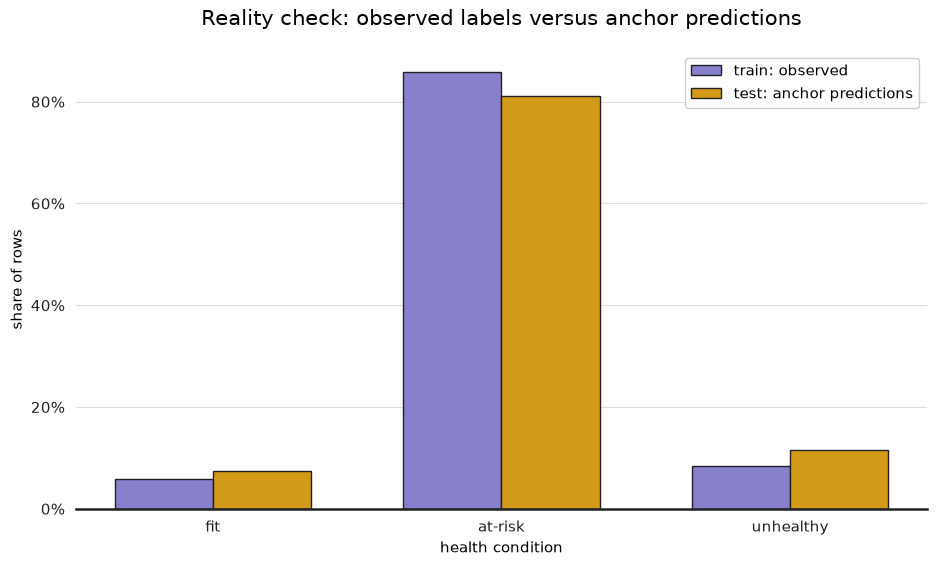

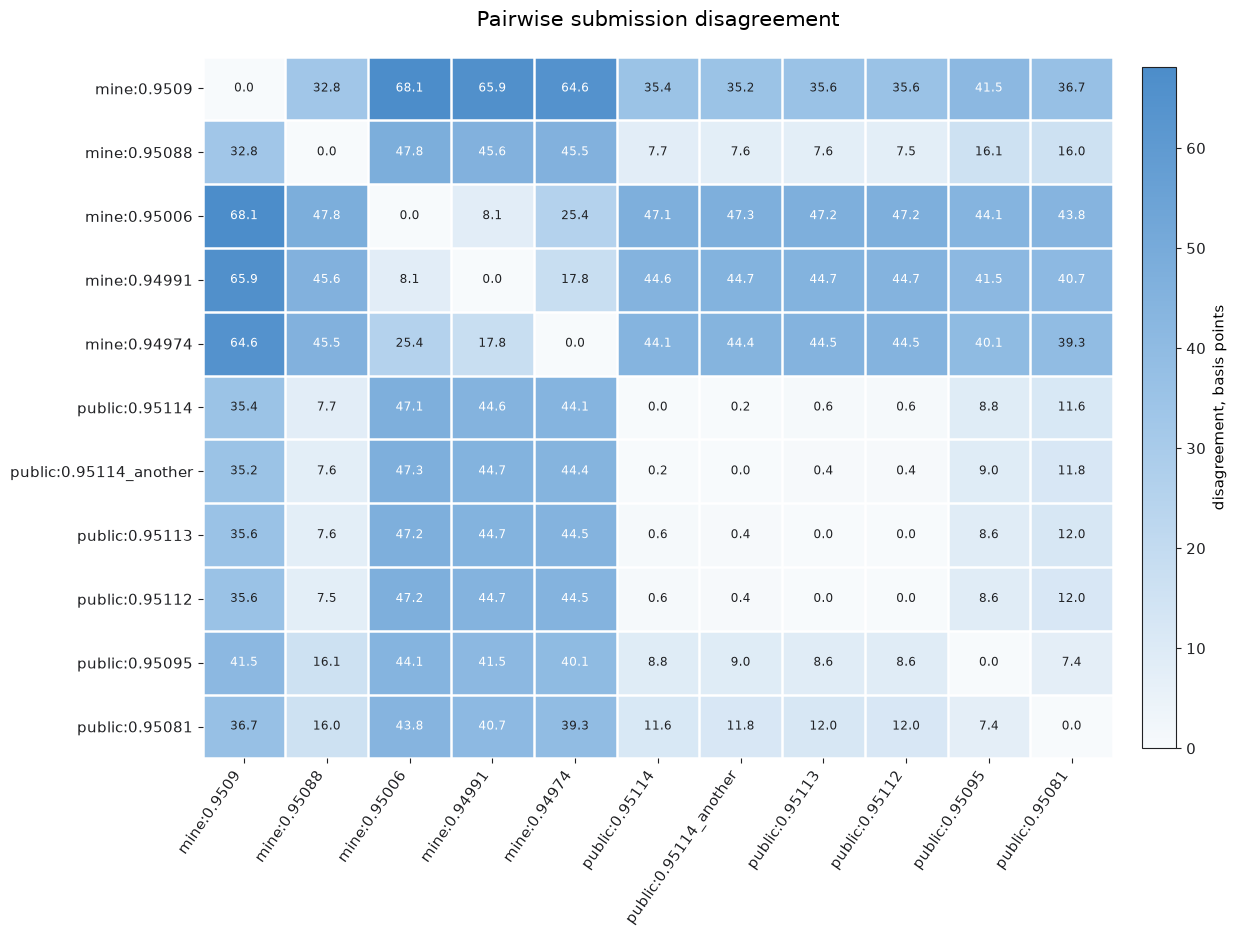

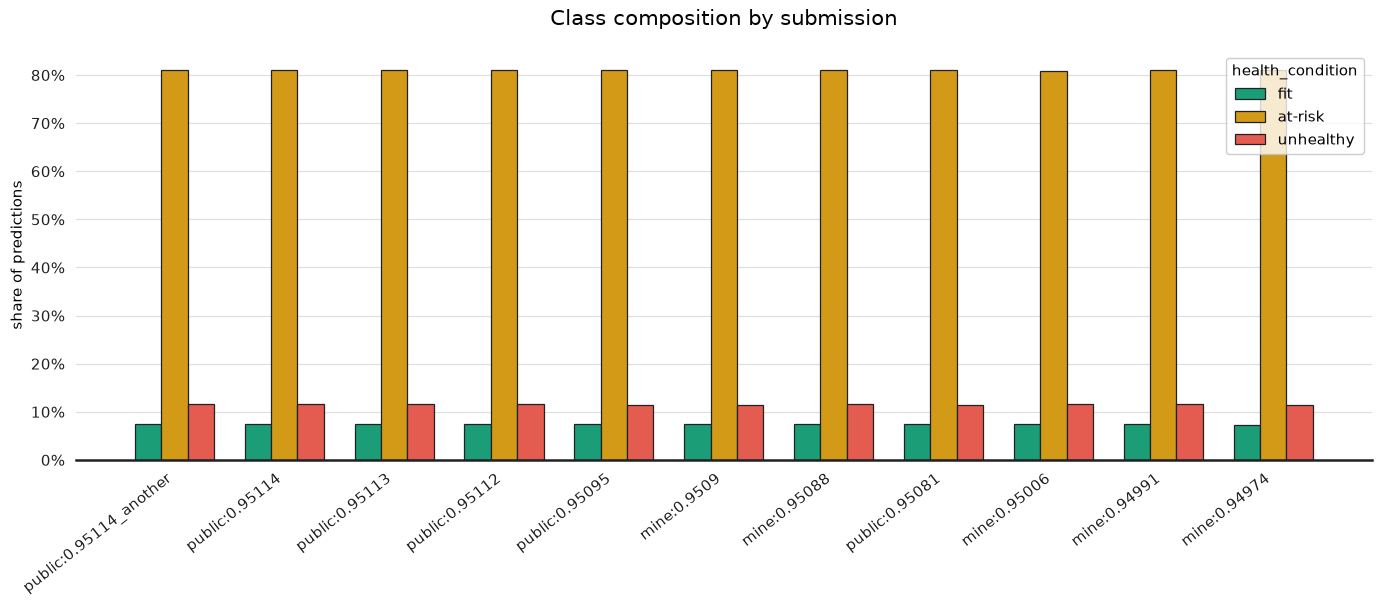

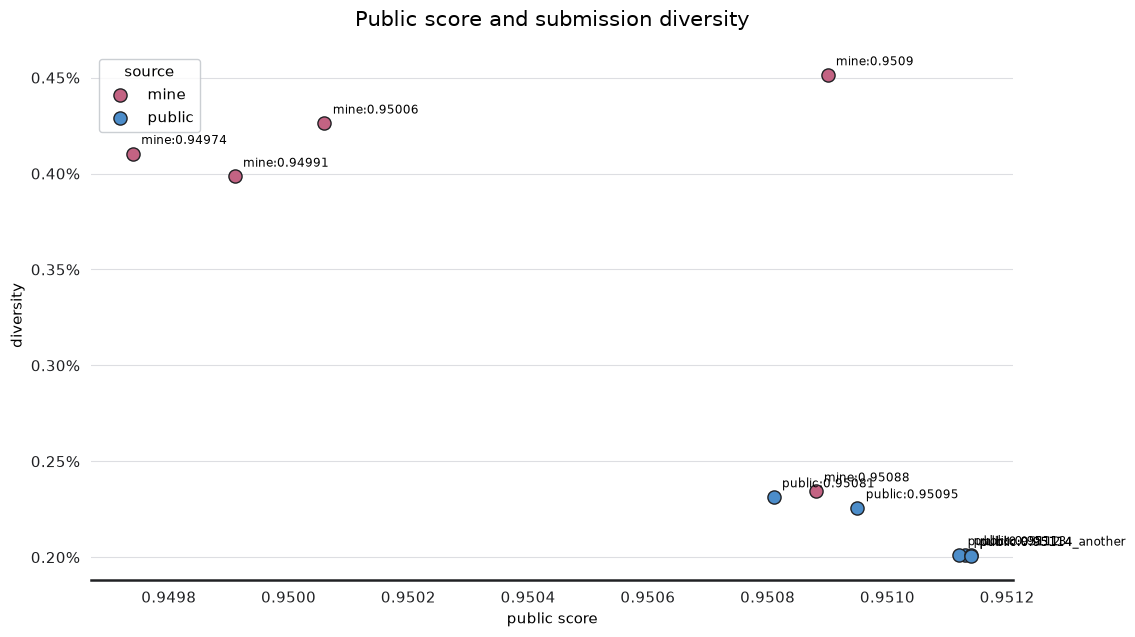

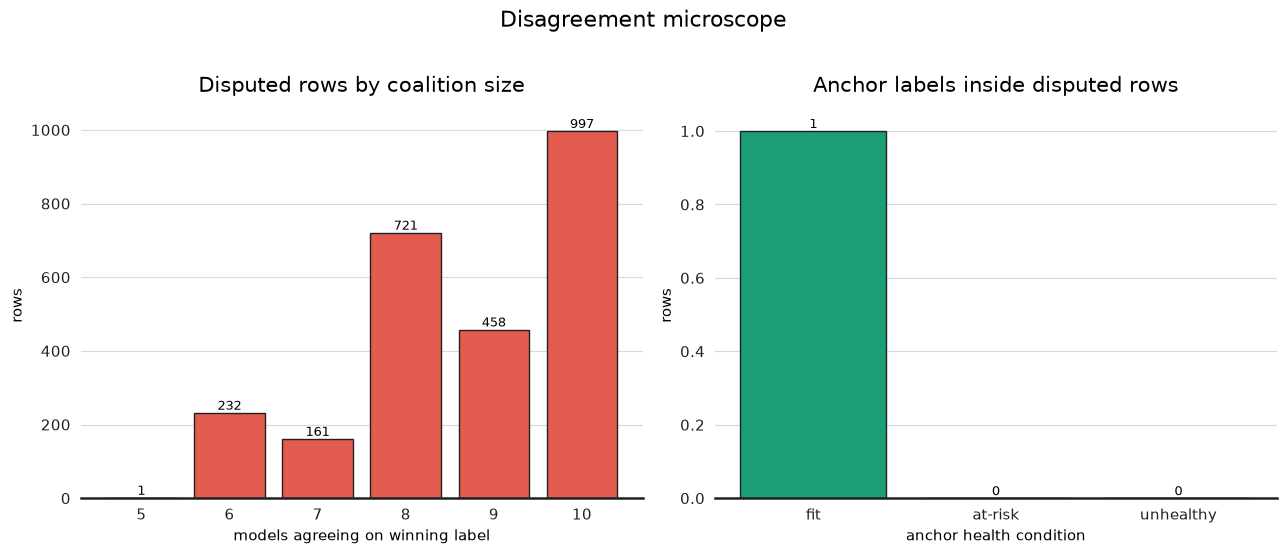

In [6]:
class BlendPlotter:
    """Creates clean outlined statistical figures on a plain white canvas."""

    def __init__(self):
        self.colors = {
            "blue": "#4C8DCA",
            "rose": "#C36383",
            "violet": "#8780CB",
            "green": "#1B9E77",
            "amber": "#D39A18",
            "coral": "#E45B4F",
            "ink": "#202124",
            "grid": "#D7D9DD",
        }
        plt.rcParams.update(
            {
                "figure.facecolor": "white",
                "axes.facecolor": "white",
                "font.size": 11,
                "font.family": "DejaVu Sans",
                "axes.titlesize": 15,
                "axes.labelsize": 11,
                "axes.edgecolor": self.colors["ink"],
                "xtick.color": self.colors["ink"],
                "ytick.color": self.colors["ink"],
            }
        )

    def _finish(self, axis, title: str, xlabel: str = "", ylabel: str = "") -> None:
        """Applies the shared outlined-axis style and renders the figure."""

        axis.set_title(title, pad=18, fontweight="normal")
        axis.set_xlabel(xlabel)
        axis.set_ylabel(ylabel)
        axis.grid(axis="y", color=self.colors["grid"], linewidth=0.8, alpha=0.85)
        axis.set_axisbelow(True)
        axis.spines["top"].set_visible(False)
        axis.spines["right"].set_visible(False)
        axis.spines["left"].set_visible(False)
        axis.spines["bottom"].set_linewidth(1.8)
        axis.spines["bottom"].set_color(self.colors["ink"])
        axis.tick_params(axis="both", length=0, pad=8)

    def disagreement_heatmap(self, agreement: pd.DataFrame) -> None:
        """Plots pairwise disagreement in basis points with outlined cells."""

        matrix = (1 - agreement) * 10_000
        figure, axis = plt.subplots(figsize=(12.5, 9.5))
        cmap = LinearSegmentedColormap.from_list("disagreement", ["#F7FAFC", "#9EC5E8", self.colors["blue"]])
        image = axis.imshow(matrix, cmap=cmap, aspect="auto")
        axis.set_xticks(np.arange(len(matrix.columns)), labels=matrix.columns, rotation=55, ha="right")
        axis.set_yticks(np.arange(len(matrix.index)), labels=matrix.index)
        axis.set_xticks(np.arange(-0.5, len(matrix.columns), 1), minor=True)
        axis.set_yticks(np.arange(-0.5, len(matrix.index), 1), minor=True)
        axis.grid(which="minor", color="white", linewidth=1.8)
        axis.tick_params(which="minor", bottom=False, left=False)
        threshold = float(matrix.to_numpy().max()) * 0.58
        for row in range(len(matrix.index)):
            for column in range(len(matrix.columns)):
                value = float(matrix.iloc[row, column])
                color = "white" if value > threshold else self.colors["ink"]
                axis.text(column, row, f"{value:.1f}", ha="center", va="center", fontsize=8.5, color=color)
        colorbar = figure.colorbar(image, ax=axis, fraction=0.035, pad=0.03)
        colorbar.set_label("disagreement, basis points")
        axis.set_title("Pairwise submission disagreement", pad=22, fontweight="normal")
        axis.set_xlabel("")
        axis.set_ylabel("")
        for spine in axis.spines.values():
            spine.set_visible(False)
        figure.tight_layout()
        plt.show()

    def class_composition(self, frame: pd.DataFrame) -> None:
        """Compares class shares using grouped bars with black outlines."""

        ordered = frame.sort_values("public_score", ascending=False)
        positions = np.arange(len(ordered))
        width = 0.24
        figure, axis = plt.subplots(figsize=(14, 6.2))
        palette = {"fit": self.colors["green"], "at-risk": self.colors["amber"], "unhealthy": self.colors["coral"]}
        for offset, label in enumerate(("fit", "at-risk", "unhealthy")):
            axis.bar(
                positions + (offset - 1) * width,
                ordered[f"share_{label}"],
                width,
                label=label,
                color=palette[label],
                edgecolor=self.colors["ink"],
                linewidth=0.9,
            )
        axis.set_xticks(positions, labels=ordered.index, rotation=38, ha="right")
        axis.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        axis.legend(title="health_condition", frameon=True, edgecolor="#BFC3C9")
        self._finish(axis, "Class composition by submission", ylabel="share of predictions")
        figure.tight_layout()
        plt.show()

    def score_diversity(self, frame: pd.DataFrame) -> None:
        """Positions candidates by public score and independent signal."""

        figure, axis = plt.subplots(figsize=(11.5, 6.5))
        source_colors = {"public": self.colors["blue"], "mine": self.colors["rose"]}
        for source, group in frame.groupby("source"):
            axis.scatter(
                group["public_score"],
                group["diversity"],
                s=90,
                color=source_colors[source],
                edgecolor=self.colors["ink"],
                linewidth=1.0,
                label=source,
                zorder=3,
            )
            for name, row in group.iterrows():
                axis.annotate(name, (row["public_score"], row["diversity"]), xytext=(6, 7), textcoords="offset points", fontsize=8.5)
        axis.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=2))
        axis.legend(title="source", frameon=True, edgecolor="#BFC3C9")
        self._finish(axis, "Public score and submission diversity", "public score", "diversity")
        figure.tight_layout()
        plt.show()

    def vote_coalition(self, values: pd.Series, total_rows: int) -> None:
        """Shows how often the largest same-label coalition has each size."""

        figure, axis = plt.subplots(figsize=(10.5, 5.8))
        bars = axis.bar(values.index.astype(str), values.values, color=self.colors["blue"], edgecolor=self.colors["ink"], linewidth=1.0)
        for bar, value in zip(bars, values.values):
            axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{int(value):,}\n({value / total_rows:.2%})", ha="center", va="bottom", fontsize=9)
        self._finish(axis, "Largest vote coalition per row", "models agreeing on winning label", "rows")
        figure.tight_layout()
        plt.show()

    def weight_heatmap(self, weights: pd.DataFrame) -> None:
        """Displays normalized candidate influence with outlined matrix cells."""

        matrix = weights.T
        figure, axis = plt.subplots(figsize=(13, 5.8))
        cmap = LinearSegmentedColormap.from_list("weights", ["#F3FAF7", "#83CCB6", self.colors["green"]])
        image = axis.imshow(matrix, cmap=cmap, aspect="auto")
        axis.set_xticks(np.arange(len(matrix.columns)), labels=matrix.columns, rotation=55, ha="right")
        axis.set_yticks(np.arange(len(matrix.index)), labels=matrix.index)
        axis.set_xticks(np.arange(-0.5, len(matrix.columns), 1), minor=True)
        axis.set_yticks(np.arange(-0.5, len(matrix.index), 1), minor=True)
        axis.grid(which="minor", color="white", linewidth=1.8)
        axis.tick_params(which="minor", bottom=False, left=False)
        for row in range(len(matrix.index)):
            for column in range(len(matrix.columns)):
                axis.text(column, row, f"{float(matrix.iloc[row, column]):.3f}", ha="center", va="center", fontsize=8.5)
        colorbar = figure.colorbar(image, ax=axis, fraction=0.035, pad=0.03)
        colorbar.set_label("normalized weight")
        axis.set_title("Candidate influence by strategy", pad=22, fontweight="normal")
        for spine in axis.spines.values():
            spine.set_visible(False)
        figure.tight_layout()
        plt.show()

    def candidate_impact(self, report: pd.DataFrame) -> None:
        """Ranks unique candidates by changed rows relative to the anchor."""

        exported = report.loc[report["exported"]].sort_values("changed_rows_vs_best", ascending=False)
        risk_colors = {"low": self.colors["green"], "medium": self.colors["amber"], "high": self.colors["coral"]}
        figure, axis = plt.subplots(figsize=(11.5, 6.2))
        bars = axis.bar(
            exported["blend_name"],
            exported["changed_rows_vs_best"],
            color=exported["risk"].map(risk_colors),
            edgecolor=self.colors["ink"],
            linewidth=1.0,
        )
        for bar, value in zip(bars, exported["changed_rows_vs_best"]):
            axis.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{int(value):,}", ha="center", va="bottom", fontsize=10)
        axis.tick_params(axis="x", rotation=30)
        self._finish(axis, "Generated candidate impact", "blend", "rows changed versus best anchor")
        figure.tight_layout()
        plt.show()



class ResearchVisualizer(BlendPlotter):
    """Adds real-data context and a focused view of disputed rows."""

    def reality_check(self, train: pd.DataFrame, predictions: pd.Series) -> None:
        """Compares observed train labels with anchor predictions on test rows."""

        labels = ("fit", "at-risk", "unhealthy")
        actual = train[config.target].value_counts(normalize=True).reindex(labels).fillna(0)
        predicted = predictions.value_counts(normalize=True).reindex(labels).fillna(0)
        positions = np.arange(len(labels))
        width = 0.34
        figure, axis = plt.subplots(figsize=(9.5, 5.8))
        axis.bar(positions - width / 2, actual, width, label="train: observed", color=self.colors["violet"], edgecolor=self.colors["ink"], linewidth=1.0)
        axis.bar(positions + width / 2, predicted, width, label="test: anchor predictions", color=self.colors["amber"], edgecolor=self.colors["ink"], linewidth=1.0)
        axis.set_xticks(positions, labels=labels)
        axis.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        axis.legend(frameon=True, edgecolor="#BFC3C9")
        self._finish(axis, "Reality check: observed labels versus anchor predictions", "health condition", "share of rows")
        figure.tight_layout()
        plt.show()
        plt.close(figure)

    def disagreement_microscope(self, predictions: pd.DataFrame, vote_strength: pd.Series, anchor_name: str) -> None:
        """Focuses on rows where the submission pool disagrees."""

        disputed = vote_strength[vote_strength.index < len(predictions.columns)]
        figure, axes = plt.subplots(1, 2, figsize=(13, 5.4))
        bars = axes[0].bar(disputed.index.astype(str), disputed.values, color=self.colors["coral"], edgecolor=self.colors["ink"], linewidth=1.0)
        for bar, value in zip(bars, disputed.values):
            axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{int(value):,}", ha="center", va="bottom", fontsize=9)
        axes[0].set_title("Disputed rows by coalition size", pad=15, fontweight="normal")
        axes[0].set_xlabel("models agreeing on winning label")
        axes[0].set_ylabel("rows")
        anchor_labels = predictions[anchor_name]
        disagreement_mask = vote_strength.reindex(predictions.index) < len(predictions.columns)
        anchor_counts = anchor_labels[disagreement_mask].value_counts().reindex(config.labels).fillna(0)
        bars = axes[1].bar(anchor_counts.index, anchor_counts.values, color=[self.colors["green"], self.colors["amber"], self.colors["coral"]], edgecolor=self.colors["ink"], linewidth=1.0)
        for bar, value in zip(bars, anchor_counts.values):
            axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{int(value):,}", ha="center", va="bottom", fontsize=9)
        axes[1].set_title("Anchor labels inside disputed rows", pad=15, fontweight="normal")
        axes[1].set_xlabel("anchor health condition")
        axes[1].set_ylabel("rows")
        for axis in axes:
            axis.spines["top"].set_visible(False)
            axis.spines["right"].set_visible(False)
            axis.spines["left"].set_visible(False)
            axis.spines["bottom"].set_linewidth(1.8)
            axis.grid(axis="y", color=self.colors["grid"], linewidth=0.8)
            axis.set_axisbelow(True)
            axis.tick_params(axis="both", length=0, pad=7)
        figure.suptitle("Disagreement microscope", fontsize=16, y=1.02, fontweight="normal")
        figure.tight_layout()
        plt.show()
        plt.close(figure)


visualizer = ResearchVisualizer()
visualizer.reality_check(train, analyzer.predictions[summary["public_score"].idxmax()])
visualizer.disagreement_heatmap(agreement)
visualizer.class_composition(summary)
visualizer.score_diversity(summary)
visualizer.disagreement_microscope(analyzer.predictions, vote_strength, summary["public_score"].idxmax())

### 5. Build transparent blends

Base strategies cover equal, score, diversity, hybrid, and cluster-balanced voting. Three additional anchor strategies change the strongest public submission only when independent model families reach 75%, 65%, or 55% weighted consensus. Prediction-identical outputs are reported but not exported twice.

blend_name,exported,duplicate_of,risk,changed_rows_vs_best,agreement_with_best
majority,True,,low,43,99.985%
score_weighted,False,majority,low,43,99.985%
diversity_weighted,True,,high,292,99.901%
hybrid,True,,medium,103,99.965%
cluster_balanced,True,,high,228,99.923%
anchor_conservative,False,anchor:public:0.95114,low,0,100.000%
anchor_balanced,True,,low,37,99.987%
anchor_aggressive,True,,high,225,99.924%


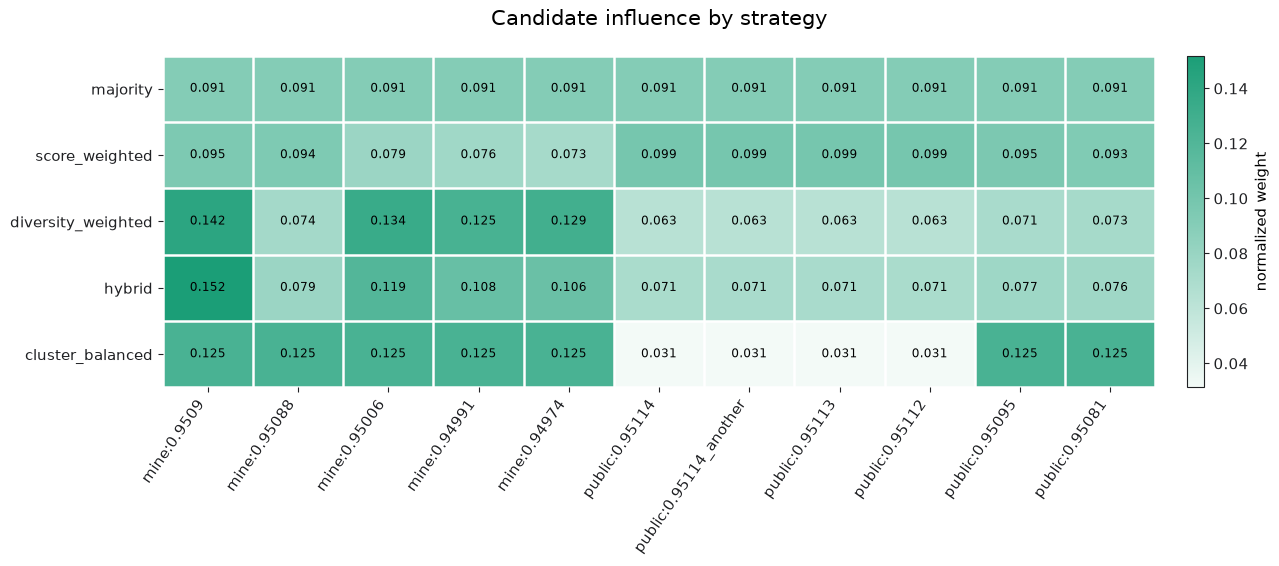

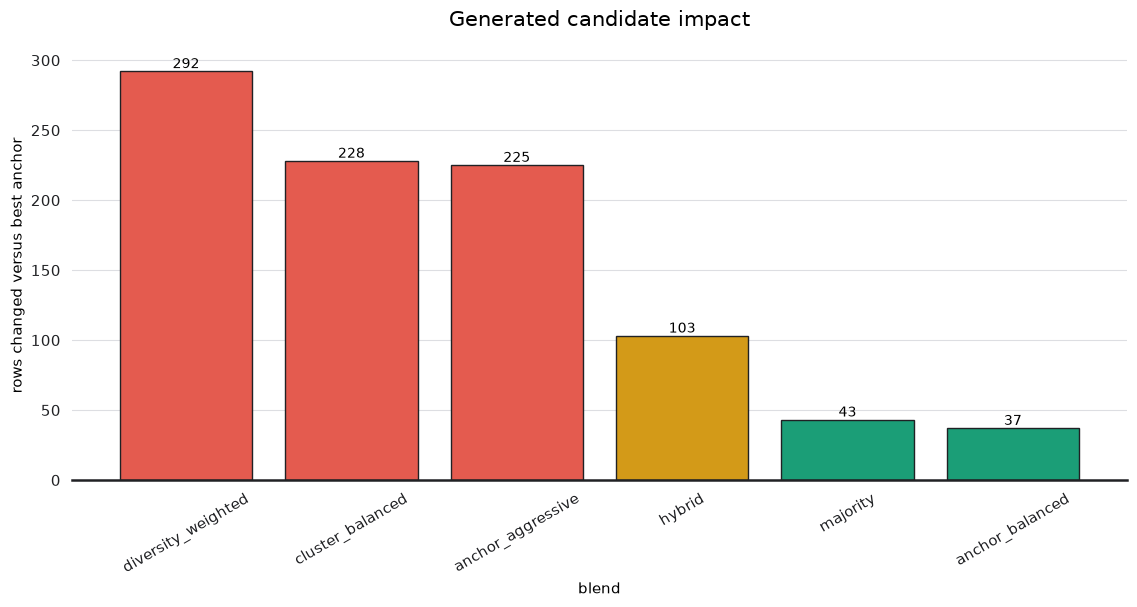

Saved unique blend artifacts to: /Users/flexonafft/MLKaggleTasks/competitions/monthly-comp/predicting-student-health-risk/health-submiss-pool/blends


In [7]:
class SubmissionBlender:
    """Creates deterministic weighted votes from aligned hard labels."""

    def __init__(self, config: BlendConfig, analyzer: SubmissionAnalyzer, summary: pd.DataFrame, agreement: pd.DataFrame):
        self.config = config
        self.analyzer = analyzer
        self.summary = summary.reindex(analyzer.predictions.columns)
        self.agreement = agreement.reindex(index=analyzer.predictions.columns, columns=analyzer.predictions.columns)
        self.names = analyzer.predictions.columns.tolist()
        self.label_to_code = {label: index for index, label in enumerate(config.labels)}
        self.encoded = analyzer.predictions.apply(lambda column: column.map(self.label_to_code)).to_numpy(dtype=np.int8)

    def _score_weights(self) -> pd.Series:
        """Applies a bounded linear preference around the median public score."""

        scores = self.summary["public_score"].fillna(self.summary["public_score"].median())
        return (1 + (scores - scores.median()) * self.config.score_weight_scale).clip(0.5, 1.5)

    def _diversity_weights(self) -> pd.Series:
        """Rewards non-duplicate signal while keeping weights bounded."""

        diversity = self.summary["diversity"].clip(lower=1e-9)
        return (diversity / diversity.mean()).clip(0.5, 2.0)

    def _duplicate_groups(self) -> list[list[str]]:
        """Finds connected groups above the near-duplicate agreement threshold."""

        parent = list(range(len(self.names)))

        def find(index: int) -> int:
            while parent[index] != index:
                parent[index] = parent[parent[index]]
                index = parent[index]
            return index

        def union(left: int, right: int) -> None:
            root_left, root_right = find(left), find(right)
            if root_left != root_right:
                parent[root_right] = root_left

        for left in range(len(self.names)):
            for right in range(left + 1, len(self.names)):
                if self.agreement.iloc[left, right] >= self.config.near_duplicate_threshold:
                    union(left, right)
        groups = {}
        for index, name in enumerate(self.names):
            groups.setdefault(find(index), []).append(name)
        return list(groups.values())

    def weight_table(self) -> pd.DataFrame:
        """Returns auditable weights for every strategy and candidate."""

        score = self._score_weights()
        diversity = self._diversity_weights()
        cluster = pd.Series(1.0, index=self.names)
        for group in self._duplicate_groups():
            cluster.loc[group] = 1 / len(group)
        weights = pd.DataFrame(
            {
                "majority": 1.0,
                "score_weighted": score,
                "diversity_weighted": diversity,
                "hybrid": score * diversity,
                "cluster_balanced": cluster,
            },
            index=self.names,
        )
        return weights.apply(lambda column: column / column.sum(), axis=0)

    def blend(self, weights: pd.Series) -> tuple[pd.DataFrame, pd.Series]:
        """Produces labels and normalized winning margins with score-based tie breaking."""

        weight_values = weights.reindex(self.names).to_numpy(dtype=float)
        totals = np.column_stack(
            [(self.encoded == code).astype(float) @ weight_values for code in range(len(self.config.labels))]
        )
        winners = totals.argmax(axis=1)
        ties = (totals == totals.max(axis=1, keepdims=True)).sum(axis=1) > 1
        if ties.any():
            best_name = self.summary["public_score"].idxmax()
            best_codes = self.encoded[:, self.names.index(best_name)]
            allowed = totals[np.arange(len(totals)), best_codes] == totals.max(axis=1)
            winners[ties & allowed] = best_codes[ties & allowed]
        labels = np.array(self.config.labels, dtype=object)[winners]
        margin = pd.Series(totals.max(axis=1) / totals.sum(axis=1), name="winning_vote_share")
        result = pd.DataFrame({self.config.id_column: self.analyzer.ids, self.config.target: labels})
        return result, margin

    def export_all(self, output: Path) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
        """Exports one competition-ready CSV per strategy and a compact report."""

        output.mkdir(parents=True, exist_ok=True)
        weights = self.weight_table()
        blends = {}
        records = []
        reference_name = self.summary["public_score"].idxmax()
        reference = self.analyzer.predictions[reference_name].to_numpy()
        for strategy in weights.columns:
            blend, margin = self.blend(weights[strategy])
            blend.to_csv(output / f"blend_{strategy}.csv", index=False)
            blends[strategy] = blend
            records.append(
                {
                    "blend_name": strategy,
                    "changed_rows_vs_best": int(np.sum(blend[self.config.target].to_numpy() != reference)),
                    "agreement_with_best": float(np.mean(blend[self.config.target].to_numpy() == reference)),
                    "mean_winning_vote_share": float(margin.mean()),
                    "minimum_winning_vote_share": float(margin.min()),
                }
            )
        report = pd.DataFrame(records)
        report.to_csv(output / "blend_report.csv", index=False)
        weights.to_csv(output / "blend_weights.csv", index_label="submission")
        return report, blends




class FamilyAwareBlender(SubmissionBlender):
    """Adds anchor overrides and exports only prediction-distinct candidates."""

    def _family_predictions(self) -> tuple[np.ndarray, list[list[str]]]:
        """Collapses each near-duplicate family into one hard-label vote."""

        groups = self._duplicate_groups()
        family_columns = []
        for group in groups:
            indices = [self.names.index(name) for name in group]
            family_values = self.encoded[:, indices]
            totals = np.column_stack([(family_values == code).sum(axis=1) for code in range(len(self.config.labels))])
            winners = totals.argmax(axis=1)
            ties = (totals == totals.max(axis=1, keepdims=True)).sum(axis=1) > 1
            if ties.any():
                best_name = self.summary.loc[group, "public_score"].idxmax()
                winners[ties] = self.encoded[ties, self.names.index(best_name)]
            family_columns.append(winners)
        return np.column_stack(family_columns), groups

    def anchor_override(self, threshold: float) -> tuple[pd.DataFrame, pd.Series]:
        """Changes the strongest anchor only under broad independent-family agreement."""

        family_predictions, groups = self._family_predictions()
        family_scores = pd.Series([self.summary.loc[group, "public_score"].max() for group in groups])
        family_weights = (1 + (family_scores - family_scores.median()) * self.config.score_weight_scale).clip(0.5, 1.5).to_numpy()
        totals = np.column_stack([(family_predictions == code).astype(float) @ family_weights for code in range(len(self.config.labels))])
        challengers = totals.argmax(axis=1)
        confidence = totals.max(axis=1) / totals.sum(axis=1)
        support = np.column_stack([(family_predictions == code).sum(axis=1) for code in range(len(self.config.labels))])
        challenger_support = support[np.arange(len(support)), challengers]
        anchor_name = self.summary["public_score"].idxmax()
        anchor_codes = self.encoded[:, self.names.index(anchor_name)]
        change = (challengers != anchor_codes) & (confidence >= threshold) & (challenger_support >= 3)
        result_codes = anchor_codes.copy()
        result_codes[change] = challengers[change]
        labels = np.array(self.config.labels, dtype=object)[result_codes]
        result = pd.DataFrame({self.config.id_column: self.analyzer.ids, self.config.target: labels})
        return result, pd.Series(confidence, name="winning_vote_share")

    def export_all(self, output: Path) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
        """Exports unique base and anchor candidates with an auditable shortlist report."""

        output.mkdir(parents=True, exist_ok=True)
        for path in output.glob("blend_*.csv"):
            path.unlink()
        weights = self.weight_table()
        candidates = {strategy: self.blend(weights[strategy]) for strategy in weights.columns}
        candidates.update(
            {
                "anchor_conservative": self.anchor_override(0.75),
                "anchor_balanced": self.anchor_override(0.65),
                "anchor_aggressive": self.anchor_override(0.55),
            }
        )
        anchor_name = self.summary["public_score"].idxmax()
        anchor = self.analyzer.predictions[anchor_name].to_numpy()
        unique_predictions = {f"anchor:{anchor_name}": anchor.copy()}
        exported_blends = {}
        records = []
        for strategy, (blend, margin) in candidates.items():
            labels = blend[self.config.target].to_numpy()
            duplicate_of = next((name for name, values in unique_predictions.items() if np.array_equal(labels, values)), "")
            exported = duplicate_of == ""
            file_name = f"blend_{strategy}.csv" if exported else ""
            if exported:
                blend.to_csv(output / file_name, index=False)
                unique_predictions[strategy] = labels.copy()
                exported_blends[strategy] = blend
            changed = int(np.sum(labels != anchor))
            risk = "low" if changed <= 75 else "medium" if changed <= 200 else "high"
            records.append(
                {
                    "blend_name": strategy,
                    "exported": exported,
                    "duplicate_of": duplicate_of,
                    "risk": risk,
                    "changed_rows_vs_best": changed,
                    "agreement_with_best": float(np.mean(labels == anchor)),
                    "mean_winning_vote_share": float(margin.mean()),
                    "minimum_winning_vote_share": float(margin.min()),
                    "file_name": file_name,
                }
            )
        report = pd.DataFrame(records)
        report.to_csv(output / "blend_candidate_report.csv", index=False)
        weights.to_csv(output / "blend_weights.csv", index_label="submission")
        return report, exported_blends


blender = FamilyAwareBlender(config, analyzer, summary, agreement)
weight_table = blender.weight_table()
blend_report, blends = blender.export_all(repository.output)
report_view = blend_report[["blend_name", "exported", "duplicate_of", "risk", "changed_rows_vs_best", "agreement_with_best"]]
display(report_view.style.format({"agreement_with_best": "{:.3%}"}).hide(axis="index"))
visualizer.weight_heatmap(weight_table)
visualizer.candidate_impact(blend_report)
print(f"Saved unique blend artifacts to: {repository.output.resolve()}")

### 6. Verify generated submissions

Every exported blend passes the same schema and identifier checks as its inputs. This is the smallest runnable guard against malformed Kaggle files.

In [8]:
generated_quality = validator.validate({f"blend:{name}": frame for name, frame in blends.items()})
assert len(blends) >= 5
assert generated_quality["schema_valid"].all()
assert generated_quality["id_order_aligned"].all()
assert all((repository.output / f"blend_{name}.csv").exists() for name in blends)
generated_view = generated_quality[["name", "rows"]].rename(columns={"name": "candidate"})
generated_view["status"] = "ready"
display(generated_view.style.hide(axis="index"))

candidate,rows,status
blend:majority,295753,ready
blend:diversity_weighted,295753,ready
blend:hybrid,295753,ready
blend:cluster_balanced,295753,ready
blend:anchor_balanced,295753,ready
blend:anchor_aggressive,295753,ready


## Probability blending

Hard-label voting can only change a small set of rows. This fast OOF section trains two compact CatBoost variants, estimates class probabilities on three folds, selects their mixture weight using OOF accuracy, and exports probability-based candidates. It is designed for a CPU run within the notebook time budget.

In [9]:
from dataclasses import dataclass


@dataclass(frozen=True)
class ProbabilityConfig:
    """Keeps the fast OOF budget explicit."""

    folds: int = 3
    iterations: int = 350
    depth: int = 7
    learning_rate: float = 0.08
    random_seed: int = 42
    thread_count: int = -1
    max_candidates: int = 2
    screening_rows: int | None = None


class ProbabilityDataRepository:
    """Resolves competition train and test data beside the submission pool."""

    def __init__(self, config: BlendConfig):
        self.config = config

    def _resolve(self, file_name: str, target: str | None = None) -> Path:
        """Finds a competition file in local and Kaggle mounts."""

        candidates = [Path(f"../dataset/{file_name}"), Path(f"dataset/{file_name}")]
        kaggle_input = Path("/kaggle/input")
        if kaggle_input.exists():
            candidates.extend(kaggle_input.rglob(file_name))
        for candidate in candidates:
            if candidate.exists():
                if target is None or target in pd.read_csv(candidate, nrows=0).columns:
                    return candidate
        raise FileNotFoundError(f"Competition {file_name} not found")

    def load(self) -> tuple[pd.DataFrame, pd.DataFrame]:
        """Loads train and test with matching feature columns."""

        train_path = self._resolve("train.csv", self.config.target)
        test_path = train_path.parent / "test.csv"
        if not test_path.exists():
            test_path = self._resolve("test.csv")
        return pd.read_csv(train_path), pd.read_csv(test_path)


class FastProbabilityRunner:
    """Runs bounded CatBoost OOF experiments and exports probability blends."""

    def __init__(self, config: BlendConfig, probability_config: ProbabilityConfig):
        self.config = config
        self.probability_config = probability_config
        self.fit_train = None
        self.available = True
        try:
            from catboost import CatBoostClassifier
            from sklearn.model_selection import StratifiedKFold
            self.CatBoostClassifier = CatBoostClassifier
            self.StratifiedKFold = StratifiedKFold
        except ImportError:
            self.available = False

    def _prepare(self, train: pd.DataFrame, test: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, list[str]]:
        """Aligns categorical and numerical columns without target leakage."""

        features = [column for column in test.columns if column != self.config.id_column]
        train_features = train[features].copy()
        test_features = test[features].copy()
        categorical = train_features.select_dtypes(include=["object", "string"]).columns.tolist()
        for column in categorical:
            train_features[column] = train_features[column].fillna("__MISSING__").astype(str)
            test_features[column] = test_features[column].fillna("__MISSING__").astype(str)
        numerical = [column for column in features if column not in categorical]
        for column in numerical:
            median = train_features[column].median()
            train_features[column] = train_features[column].fillna(median)
            test_features[column] = test_features[column].fillna(median)
        return train_features, test_features, categorical

    def run(self, train: pd.DataFrame, test: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
        """Returns OOF probabilities, test probabilities, and model scores."""

        if not self.available:
            print("CatBoost or scikit-learn unavailable; probability section skipped.")
            return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()
        if self.probability_config.screening_rows is not None and len(train) > self.probability_config.screening_rows:
            train = train.sample(self.probability_config.screening_rows, random_state=self.probability_config.random_seed).reset_index(drop=True)
        self.fit_train = train
        x_train, x_test, categorical = self._prepare(train, test)
        y = train[self.config.target].to_numpy()
        labels = list(self.config.labels)
        cat_indices = [x_train.columns.get_loc(column) for column in categorical]
        splitter = self.StratifiedKFold(n_splits=self.probability_config.folds, shuffle=True, random_state=self.probability_config.random_seed)
        oof_models = [np.zeros((len(train), len(labels))) for _ in range(self.probability_config.max_candidates)]
        test_models = [np.zeros((len(test), len(labels))) for _ in range(self.probability_config.max_candidates)]
        model_scores = []
        for model_index in range(self.probability_config.max_candidates):
            for fold, (fit_index, valid_index) in enumerate(splitter.split(x_train, y)):
                model = self.CatBoostClassifier(
                    iterations=self.probability_config.iterations,
                    depth=self.probability_config.depth + model_index,
                    learning_rate=self.probability_config.learning_rate,
                    loss_function="MultiClass",
                    class_names=labels,
                    eval_metric="MultiClass",
                    auto_class_weights="Balanced",
                    random_seed=self.probability_config.random_seed + model_index * 101 + fold,
                    verbose=False,
                    thread_count=self.probability_config.thread_count,
                    allow_writing_files=False,
                )
                model.fit(x_train.iloc[fit_index], y[fit_index], cat_features=cat_indices, eval_set=(x_train.iloc[valid_index], y[valid_index]), early_stopping_rounds=35)
                oof_models[model_index][valid_index] = model.predict_proba(x_train.iloc[valid_index])
                test_models[model_index] += model.predict_proba(x_test) / self.probability_config.folds
            predictions = np.array(labels)[oof_models[model_index].argmax(axis=1)]
            from sklearn.metrics import balanced_accuracy_score
            model_scores.append({"model": f"catboost_depth_{self.probability_config.depth + model_index}", "oof_balanced_accuracy": balanced_accuracy_score(y, predictions)})
        oof = pd.DataFrame({f"model_{index}_{label}": oof_models[index][:, label_index] for index in range(len(oof_models)) for label_index, label in enumerate(labels)})
        test_probabilities = pd.DataFrame({f"model_{index}_{label}": test_models[index][:, label_index] for index in range(len(test_models)) for label_index, label in enumerate(labels)})
        return oof, test_probabilities, pd.DataFrame(model_scores)

    def select_weight(self, oof: pd.DataFrame, train: pd.DataFrame) -> tuple[float, pd.DataFrame]:
        """Selects two-model weight using a small OOF grid."""

        if oof.empty:
            return 0.5, pd.DataFrame()
        labels = list(self.config.labels)
        first = oof[[f"model_0_{label}" for label in labels]].to_numpy()
        second = oof[[f"model_1_{label}" for label in labels]].to_numpy()
        y = train[self.config.target].to_numpy()
        from sklearn.metrics import balanced_accuracy_score
        candidates = []
        for weight in np.linspace(0, 1, 21):
            probabilities = weight * first + (1 - weight) * second
            prediction = np.array(labels)[probabilities.argmax(axis=1)]
            candidates.append({"model_0_weight": weight, "model_1_weight": 1 - weight, "oof_balanced_accuracy": balanced_accuracy_score(y, prediction)})
        report = pd.DataFrame(candidates).sort_values("oof_balanced_accuracy", ascending=False).reset_index(drop=True)
        return float(report.loc[0, "model_0_weight"]), report


probability_config = ProbabilityConfig()
probability_data = ProbabilityDataRepository(config)
probability_train, probability_test = probability_data.load()
probability_runner = FastProbabilityRunner(config, probability_config)
oof_probabilities, test_probabilities, probability_model_report = probability_runner.run(probability_train, probability_test)
probability_weight, probability_weight_report = probability_runner.select_weight(oof_probabilities, probability_runner.fit_train)
probability_model_report.to_csv(repository.output / "probability_model_report.csv", index=False)
probability_weight_report.to_csv(repository.output / "probability_weight_report.csv", index=False)
display(probability_model_report)
display(probability_weight_report.head(5))


CatBoost or scikit-learn unavailable; probability section skipped.


""


""


In [10]:
class ProbabilitySubmissionFactory:
    """Creates prior-corrected and anchor-gated probability submissions."""

    def __init__(self, config: BlendConfig, test: pd.DataFrame, probabilities: pd.DataFrame, weight: float, anchor: pd.Series, output: Path):
        self.config = config
        self.test = test
        self.probabilities = probabilities
        self.weight = weight
        self.anchor = anchor.reset_index(drop=True)
        self.output = output
        self.max_changes = 3000

    def _calibrate_prior(self, probabilities: np.ndarray) -> np.ndarray:
        """Corrects train-prior drift toward the strong community anchor prior."""

        labels = list(self.config.labels)
        model_prior = probabilities.mean(axis=0)
        anchor_prior = self.anchor.value_counts(normalize=True).reindex(labels).fillna(0).to_numpy()
        adjusted = probabilities * (anchor_prior / np.maximum(model_prior, 1e-9))
        return adjusted / adjusted.sum(axis=1, keepdims=True)

    def _anchor_gate(self, probabilities: np.ndarray) -> np.ndarray:
        """Allows only the highest-confidence changes, capped at 3000 rows."""

        labels = np.array(self.config.labels)
        prediction = labels[probabilities.argmax(axis=1)]
        confidence = probabilities.max(axis=1)
        changes = prediction != self.anchor.to_numpy()
        ranking = np.argsort(-(confidence - np.partition(probabilities, -2, axis=1)[:, -2]))
        accepted = np.zeros(len(prediction), dtype=bool)
        accepted[ranking[: self.max_changes]] = True
        return np.where(changes & accepted, prediction, self.anchor.to_numpy())

    def export(self) -> pd.DataFrame:
        """Exports corrected probability candidates and a compact diagnostic report."""

        if self.probabilities.empty:
            return pd.DataFrame()
        labels = list(self.config.labels)
        first = self.probabilities[[f"model_0_{label}" for label in labels]].to_numpy()
        second = self.probabilities[[f"model_1_{label}" for label in labels]].to_numpy()
        raw_candidates = {
            "probability_average": 0.5 * first + 0.5 * second,
            "probability_oof_weighted": self.weight * first + (1 - self.weight) * second,
        }
        calibrated = {name: self._calibrate_prior(probabilities) for name, probabilities in raw_candidates.items()}
        candidates = {
            "probability_prior_corrected": calibrated["probability_oof_weighted"],
            "probability_anchor_gated_3000": calibrated["probability_oof_weighted"],
        }
        records = []
        self.output.mkdir(parents=True, exist_ok=True)
        for path in self.output.glob("blend_probability*.csv"):
            path.unlink()
        for name, probabilities in candidates.items():
            prediction = np.array(labels)[probabilities.argmax(axis=1)] if name.endswith("prior_corrected") else self._anchor_gate(probabilities)
            submission = pd.DataFrame({self.config.id_column: self.test[self.config.id_column], self.config.target: prediction})
            path = self.output / f"blend_{name}.csv"
            submission.to_csv(path, index=False)
            records.append({"blend_name": name, "file_name": path.name, "mean_confidence": float(probabilities.max(axis=1).mean()), "low_confidence_rows": int(np.sum(probabilities.max(axis=1) < 0.55)), "changed_vs_anchor": int(np.sum(prediction != self.anchor.to_numpy()))})
        report = pd.DataFrame(records)
        report.to_csv(self.output / "probability_candidate_report.csv", index=False)
        return report


probability_factory = ProbabilitySubmissionFactory(config, probability_test, test_probabilities, probability_weight, analyzer.predictions[summary["public_score"].idxmax()], repository.output)
probability_candidate_report = probability_factory.export()
display(probability_candidate_report)


""


## Takeaways

- Prefer candidates that balance score and diversity, not score alone.
- Treat near-identical files as one prediction family.
- Submit a small set of meaningfully different blends rather than many tiny weight variants.
- Upgrade to probability blending only when raw class probabilities or OOF predictions become available.

### Probability iteration

The probability section is intentionally bounded to three folds and two compact CatBoost variants. OOF accuracy selects the mixture weight; public leaderboard scores remain an external check, not a tuning target.

In [11]:
class NotebookSummary:
    """Prints final observed facts after every calculation succeeds."""

    @staticmethod
    def show(catalog: pd.DataFrame, agreement: pd.DataFrame, vote_strength: pd.Series, report: pd.DataFrame) -> None:
        """Reports pool size, disagreement, duplicate intensity, and generated artifacts."""

        off_diagonal = agreement.to_numpy()[~np.eye(len(agreement), dtype=bool)]
        total_rows = len(analyzer.predictions)
        unanimous_rows = int(vote_strength.get(len(catalog), 0))
        print(f"Candidates: {len(catalog)}")
        print(f"Rows: {total_rows:,}")
        print(f"Unanimous rows: {unanimous_rows:,} ({unanimous_rows / total_rows:.3%})")
        print(f"Pairwise agreement range: {off_diagonal.min():.3%} to {off_diagonal.max():.3%}")
        print(f"Generated unique blends: {', '.join(report.loc[report['exported'], 'blend_name'])}")


NotebookSummary.show(catalog, agreement, vote_strength, blend_report)

Candidates: 11
Rows: 295,753
Unanimous rows: 293,183 (99.131%)
Pairwise agreement range: 99.319% to 100.000%
Generated unique blends: majority, diversity_weighted, hybrid, cluster_balanced, anchor_balanced, anchor_aggressive
